In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import tensorflow as tf
print(tf.keras.__version__)

3.13.2


FruitinAmazon dataset is a collection of images specifically curated to represent various types of fruits (like Apples, Bananas, Oranges, etc.).

In [6]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    Dropout, BatchNormalization, Activation,
    GlobalAveragePooling2D
)
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [7]:
import zipfile, os

ZIP_PATH = "/content/drive/MyDrive/Colab Notebooks/AI_ML_Practice/Week5/FruitinAmazon.zip" # location of my zipfile

EXTRACT_DIR = "./fruitnamazon_dataset" # under current directory (./) create the new folder to store extracted dataset
os.makedirs(EXTRACT_DIR, exist_ok=True) # this is where it actually gets created.

# Unzip the file
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)
print(f"File '{os.path.basename(ZIP_PATH)}' unzipped to '{EXTRACT_DIR}'")

File 'FruitinAmazon.zip' unzipped to './fruitnamazon_dataset'


##Task 1: Data Understanding and Visualization:

1. Load and visualize images from a dataset stored in directories, where each subdirec-
tory represents a class.

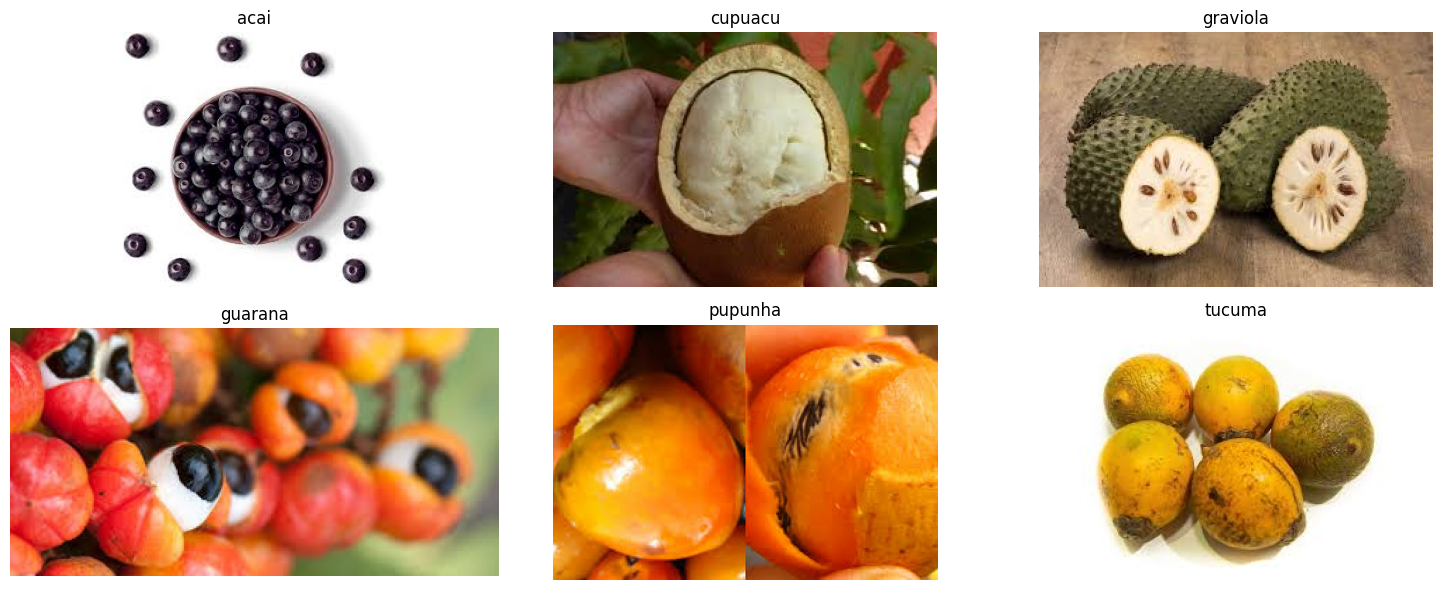

In [8]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# training data path
train_dir = "/content/fruitnamazon_dataset/FruitinAmazon/train"
test_dir = "/content/fruitnamazon_dataset/FruitinAmazon/test"

# finds list of folder and each folder is class, folder: apple, banana, orange etc.
class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])

# calculates how many columns we need to fit all classes into exactly 2 rows
num_classes = len(class_names)
cols = (num_classes + 1) // 2  # Calculate columns needed for 2 rows
plt.figure(figsize=(15, 6))

# Random Selection Loop and plots
for i, class_name in enumerate(class_names):
    class_path = os.path.join(train_dir, class_name)
    random_img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, random_img_name)

    img = Image.open(img_path)

    plt.subplot(2, cols, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

Check for Corrupted Image:

In [9]:

corrupted_images = []

# Iterate through each class subdirectory
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    for filename in os.listdir(class_path):
        image_path = os.path.join(class_path, filename)

        try:
            # Attempt to load and verify the image
            with Image.open(image_path) as img:
                img.verify()
        except (IOError, SyntaxError):
            # If corrupted, remove and record
            print(f"Removed corrupted image: {image_path}")
            os.remove(image_path)
            corrupted_images.append(image_path)


if not corrupted_images:
    print("No Corrupted Images Found.")
else:
    print(f"Cleaned up {len(corrupted_images)} images.")

No Corrupted Images Found.


##Task 2: Loading and Preprocessing Image Data in keras:

In [10]:
img_height = 128 # Example image height
img_width = 128 # Example image width
batch_size = 32
validation_split = 0.2 # 80% training, 20% validation
NUM_CLASSES = len(class_names)
IMAGE_SIZE  = (224, 224)  # Width x Height — matches VGG16 input
BATCH_SIZE  = 32

#Pixel values are 0–255, dividing by 255 brings them to 0–1.
rescale = tf.keras.layers.Rescaling(1./255)

# 3. Create training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',     #tells label to use subfolder names
    label_mode='int', #Encode labels as integers — apple=0, banana=1, mango=2 etc. Required for sparse_categorical_crossentropy.
    image_size=(img_height, img_width), # Changed to (img_height, img_width) to match model's input_shape
    interpolation='nearest', #When resizing, fill new pixels by copying the nearest original pixel. Simple and fast.
    batch_size=batch_size,
    shuffle=True, #Randomise order every epoch so the model doesn't learn class order instead of patterns.
    validation_split=validation_split,
    subset='training', #This call gets the 80% training portion. The val_ds call below gets the other 20%
    seed=123 #guarantes the same 80/20 split every time, no image appears in both.
)

# 4. Create validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width), # Changed to (img_height, img_width) to match model's input_shape
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,              # Validation should not be shuffled
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# 5. Apply Normalization to both
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

print("\nDatasets are loaded and normalized!")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.

Datasets are loaded and normalized!


In [11]:
from tensorflow.keras import layers, models

#  lists everything inside the train folder
#  filters to folders only
class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
num_classes = len(class_names)

print(f"Building model for {num_classes} classes: {class_names}\n")

# Build the Sequential Model
model = models.Sequential([
    # --- Convolutional Architecture ---

    # Convolutional Layer 1
    # create 32 filters, producing 32 feature maps. Each filter learns a different pattern — edges, curves,
    # each filter is a 3×3 grid of learnable numbers sliding across the image.
    # move the filter one pixel at a time horizontally and vertically.
    # adds zeros around the border so output spatial size = input spatial size
    layers.Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1),
                  padding='same', activation='relu', input_shape=(128, 128, 3)),

    #window that slides across the feature map taking the maximum value from each 2×2 region.
    # jumps 2 pixels each time, so windows don't overlap. This is what halves the spatial size.
    layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    # Convolutional Layer 2
    layers.Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1),
                  padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    # --- Fully Connected Network Architecture ---
    layers.Flatten(),

    # Hidden Layer 1 (64 neurons)
    layers.Dense(64, activation='relu'),

    # Hidden Layer 2 (128 neurons)
    layers.Dense(128, activation='relu'),

    # Output Layer
    # one neuron per fruit class.
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Building model for 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

Task 4: Compile and Train the Model

In [12]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


model.compile(
    optimizer='adam', #tells Keras how to update weights during backward propagation. Adam automatically adapts the learning rate η per weight
    loss='sparse_categorical_crossentropy', #  labels are integers
    metrics=['accuracy']
)


# ModelCheckpoint saves the best version based on validation loss
checkpoint = ModelCheckpoint(
    'best_fruit_model.h5',
    monitor='val_loss', # Watch validation loss, not training loss.
    save_best_only=True, #Only overwrite best_fruit_model.h5 when val_loss improves. Without this, every epoch overwrites the file
    verbose=1 # Print a message when the model is saved
)

# EarlyStopping stops training if val_loss doesn't improve for 10 epochs
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)


history = model.fit(
    train_ds,
    epochs=250,
    validation_data=val_ds,
    callbacks=[checkpoint, early_stop]
)



Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 953ms/step - accuracy: 0.1950 - loss: 1.9525
Epoch 1: val_loss improved from None to 2.49543, saving model to best_fruit_model.h5



Epoch 1: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.1944 - loss: 2.0409 - val_accuracy: 0.0000e+00 - val_loss: 2.4954
Epoch 2/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.1562 - loss: 1.7949
Epoch 2: val_loss improved from 2.49543 to 1.38903, saving model to best_fruit_model.h5



Epoch 2: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.2222 - loss: 1.7657 - val_accuracy: 0.8333 - val_loss: 1.3890
Epoch 3/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.2500 - loss: 1.6022
Epoch 3: val_loss did not improve from 1.38903
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3333 - loss: 1.5661 - val_accuracy: 0.1111 - val_loss: 2.0585
Epoch 4/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.1875 - loss: 1.6378
Epoch 4: val_loss improved from 1.38903 to 1.38896, saving model to best_fruit_model.h5



Epoch 4: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.3472 - loss: 1.4423 - val_accuracy: 0.3889 - val_loss: 1.3890
Epoch 5/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.6562 - loss: 1.1689
Epoch 5: val_loss improved from 1.38896 to 1.14757, saving model to best_fruit_model.h5



Epoch 5: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.6250 - loss: 1.1758 - val_accuracy: 0.6111 - val_loss: 1.1476
Epoch 6/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.6875 - loss: 1.0000
Epoch 6: val_loss improved from 1.14757 to 0.88647, saving model to best_fruit_model.h5


...


Epoch 8: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.8333 - loss: 0.5529 - val_accuracy: 0.7778 - val_loss: 0.7202
Epoch 9/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9375 - loss: 0.2530
Epoch 9: val_loss improved from 0.72016 to 0.40155, saving model to best_fruit_model.h5



Epoch 9: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.9167 - loss: 0.3281 - val_accuracy: 0.9444 - val_loss: 0.4015
Epoch 10/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9688 - loss: 0.1928
Epoch 10: val_loss did not improve from 0.40155
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9722 - loss: 0.2333 - val_accuracy: 0.6667 - val_loss: 0.5836
Epoch 11/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 1.0000 - loss: 0.1877
Epoch 11: val_loss did not improve from 0.40155
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9861 - loss: 0.1546 - val_accuracy: 0.6667 - val_loss: 1.0971
Epoch 12/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.9688 - loss: 0.1117
Epoch 12: val_loss did not improve from 0.40155
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9583 - loss: 0.1319 - val_accuracy: 0.8333 - val_loss: 0.5720
Epoch 13/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 1.0000 - loss: 0.0523
Epoc


Epoch 13: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 1.0000 - loss: 0.0772 - val_accuracy: 0.9444 - val_loss: 0.2558
Epoch 14/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 1.0000 - loss: 0.0299
Epoch 14: val_loss did not improve from 0.25578
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 1.0000 - loss: 0.0361 - val_accuracy: 0.8333 - val_loss: 0.2850
Epoch 15/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 1.0000 - loss: 0.0298
Epoch 15: val_loss did not improve from 0.25578
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 1.0000 - loss: 0.0220 - val_accuracy: 0.8333 - val_loss: 0.4607
Epoch 16/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 1.0000 - loss: 0.0126
Epoch 16: val_loss did not improve from 0.25578
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 1.0000 - loss: 0.0106 - val_accuracy: 0.8333 - val_loss: 0.5701
Epoch 17/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 1.0000 - loss: 0.0113
Epoc


Epoch 22: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.8889 - val_loss: 0.2273
Epoch 23/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 1.0000 - loss: 0.0010
Epoch 23: val_loss improved from 0.22727 to 0.22121, saving model to best_fruit_model.h5



Epoch 23: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 0.9444 - val_loss: 0.2212
Epoch 24/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 1.0000 - loss: 0.0012
Epoch 24: val_loss did not improve from 0.22121
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 1.0000 - loss: 9.0649e-04 - val_accuracy: 0.9444 - val_loss: 0.2359
Epoch 25/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 1.0000 - loss: 9.8645e-04
Epoch 25: val_loss did not improve from 0.22121
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 1.0000 - loss: 8.5342e-04 - val_accuracy: 0.9444 - val_loss: 0.2511
Epoch 26/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 1.0000 - loss: 6.2518e-04
Epoch 26: val_loss did not improve from 0.22121
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 1.0000 - loss: 7.7589e-04 - val_accuracy: 0.9444 - val_loss: 0.2651
Epoch 27/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 1.00

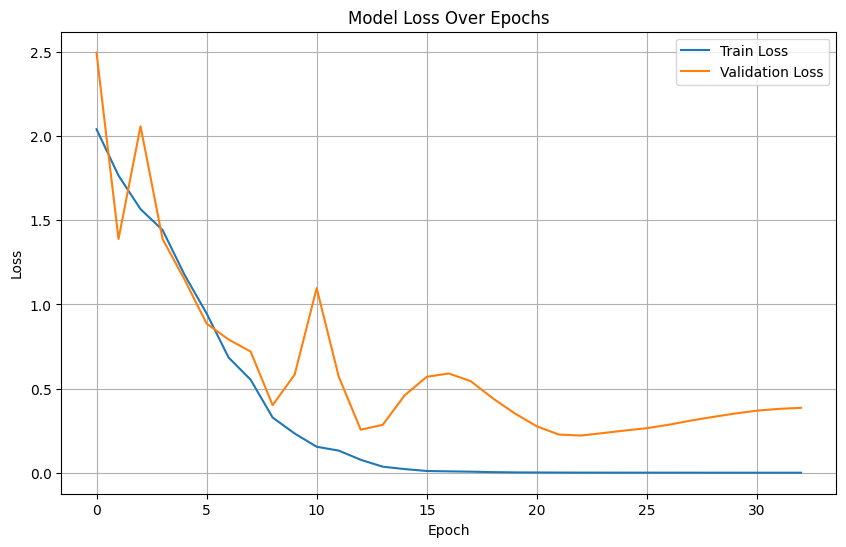

In [13]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

Task 5: Evaluate the Model

In [14]:
# --- Task 5: Evaluate the Model ---
print("\n--- Final Evaluation on Validation Set ---")
val_loss, val_accuracy = model.evaluate(val_ds)
print(f"Loss: {val_loss:.4f}, Accuracy: {val_accuracy:.4f}")


--- Final Evaluation on Validation Set ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9444 - loss: 0.2212
Loss: 0.2212, Accuracy: 0.9444


Task 6: Save and Load the Model

In [15]:
from tensorflow.keras.models import load_model

# 1. Save the model explicitly
model.save('final_fruit_model.h5')
print("Model saved successfully as 'final_fruit_model.h5'")

# 2. Load the saved model (using the 'best' one saved by our checkpoint)
loaded_model = load_model('best_fruit_model.h5')
print("Best version of the model reloaded successfully!")

# 3. Re-evaluate to prove it works
re_loss, re_acc = loaded_model.evaluate(val_ds)
print(f"Reloaded Model Accuracy: {re_acc*100:.2f}%")

Model saved successfully as 'final_fruit_model.h5'


Best version of the model reloaded successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 643ms/step - accuracy: 0.9444 - loss: 0.2212
Reloaded Model Accuracy: 94.44%


Task 7: Predictions and Classification Report

In [16]:
from sklearn.metrics import classification_report
import numpy as np
import tensorflow as tf

# 1. Load test dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size= (128,128),
    batch_size=32,
    label_mode='int',
    shuffle=False
)

# 2. Normalise test data
rescale = tf.keras.layers.Rescaling(1./255)
test_ds_scaled = test_ds.map(lambda x, y: (rescale(x), y))

# 3. Extract ground truth and predictions
y_true = []
y_pred_probs = []

print("Generating predictions on test set...")
for images, labels in test_ds_scaled:
    preds = loaded_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred_probs.extend(preds)

y_pred = np.argmax(y_pred_probs, axis=1)

# 4. Get class names from test folder
class_names = sorted([
    d for d in os.listdir(test_dir)
    if os.path.isdir(os.path.join(test_dir, d))
])

# 5. Generate report for all 6 classes
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print("\n--- FINAL CLASSIFICATION REPORT (TEST SET) ---")
print(report)

Found 30 files belonging to 6 classes.
Generating predictions on test set...

--- FINAL CLASSIFICATION REPORT (TEST SET) ---
              precision    recall  f1-score   support

        acai       0.80      0.80      0.80         5
     cupuacu       0.60      0.60      0.60         5
    graviola       0.62      1.00      0.77         5
     guarana       0.60      0.60      0.60         5
     pupunha       0.67      0.40      0.50         5
      tucuma       0.50      0.40      0.44         5

    accuracy                           0.63        30
   macro avg       0.63      0.63      0.62        30
weighted avg       0.63      0.63      0.62        30



week6


In [17]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input
# Hyperparameters
IMG_SIZE   = (224, 224)   # VGG16 native input size
BATCH_SIZE = 32

# VGG16 expects pixel values preprocessed via preprocess_input
# Training generator — with augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.15
)

# Test generator — no augmentation
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\nTrain batches      : {len(train_gen)}")
print(f"Validation batches : {len(val_gen)}")
print(f"Test batches       : {len(test_gen)}")

Found 78 images belonging to 6 classes.
Found 12 images belonging to 6 classes.
Found 30 images belonging to 6 classes.

Train batches      : 3
Validation batches : 1
Test batches       : 1


In [19]:
base_model = VGG16(
    weights='imagenet',      # Use ImageNet pre-trained weights
    include_top=False,       # Remove the original output layer
    input_shape=(*IMG_SIZE, 3)
)


print(f'VGG16 loaded. Total layers: {len(base_model.layers)}')

VGG16 loaded. Total layers: 19


In [20]:
# Freeze ALL base layers
base_model.trainable = False

print(f"VGG16 base layers  : {len(base_model.layers)}")
print(f"Trainable params   : {base_model.count_params():,}   all frozen")

VGG16 base layers  : 19
Trainable params   : 14,714,688   all frozen


In [21]:
# Build on top of VGG16's output
inputs  = keras.Input(shape=(*IMG_SIZE, 3))
x       = base_model(inputs, training=False)   # BN layers stay in inference mode
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(512, activation='relu')(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

feature_model = Model(inputs, outputs, name='VGG16_FeatureExtraction')

In [22]:
#  Compile with Adam
feature_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

feature_model.summary()

Model: "VGG16_FeatureExtraction"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,113,286 (57.65 MB)

 Trainable params: 397,062 (1.51 MB)

 Non-trainable params: 14,716,224 (56.14 MB)

In [23]:
EPOCHS_PHASE1 = 50

callbacks_phase1 = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_feature_model.h5',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print('=' * 55)
print('  PHASE 1 — Feature Extraction Training')
print('=' * 55)

history_phase1 = feature_model.fit(
    train_gen,
    epochs=EPOCHS_PHASE1,
    validation_data=val_gen,
    callbacks=callbacks_phase1,
    verbose=1
)

# Evaluate on test set
loss_p1, acc_p1 = feature_model.evaluate(test_gen, verbose=0)
print(f"\n[Phase 1] Test Loss     : {loss_p1:.4f}")
print(f"[Phase 1] Test Accuracy : {acc_p1*100:.2f}%")

  PHASE 1 — Feature Extraction Training
Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.1998 - loss: 2.4372
Epoch 1: val_accuracy improved from None to 0.25000, saving model to best_feature_model.h5



Epoch 1: finished saving model to best_feature_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 34s 8s/step - accuracy: 0.2692 - loss: 2.2874 - val_accuracy: 0.2500 - val_loss: 1.8111 - learning_rate: 0.0010
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.5820 - loss: 1.0530
Epoch 2: val_accuracy improved from 0.25000 to 0.75000, saving model to best_feature_model.h5



Epoch 2: finished saving model to best_feature_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 644ms/step - accuracy: 0.5897 - loss: 1.0644 - val_accuracy: 0.7500 - val_loss: 0.5046 - learning_rate: 0.0010
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 658ms/step - accuracy: 0.8656 - loss: 0.4826
Epoch 3: val_accuracy improved from 0.75000 to 0.83333, saving model to best_feature_model.h5



Epoch 3: finished saving model to best_feature_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.8205 - loss: 0.5302 - val_accuracy: 0.8333 - val_loss: 0.4801 - learning_rate: 0.0010
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.7760 - loss: 0.5277
Epoch 4: val_accuracy improved from 0.83333 to 1.00000, saving model to best_feature_model.h5



Epoch 4: finished saving model to best_feature_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 675ms/step - accuracy: 0.8590 - loss: 0.3673 - val_accuracy: 1.0000 - val_loss: 0.0216 - learning_rate: 0.0010
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.8539 - loss: 0.3967
Epoch 5: val_accuracy did not improve from 1.00000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 582ms/step - accuracy: 0.8846 - loss: 0.3172 - val_accuracy: 1.0000 - val_loss: 0.1362 - learning_rate: 0.0010
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.9318 - loss: 0.2467
Epoch 6: val_accuracy did not improve from 1.00000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 400ms/step - accuracy: 0.9359 - loss: 0.2202 - val_accuracy: 1.0000 - val_loss: 0.0371 - learning_rate: 0.0010
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - accuracy: 0.9706 - loss: 0.1182
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 7: val_accuracy did not improve from 1.00000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 387ms/step - acc

In [28]:
#  Rebuild identical architecture
base_model_ft = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(*IMG_SIZE, 3)
)

In [29]:
# Freeze all EXCEPT the last convolutional block (block5)
FINE_TUNE_AT = len(base_model_ft.layers) - 2  # unfreeze last 2 layers
for layer in base_model_ft.layers[:FINE_TUNE_AT]:
    layer.trainable = False
for layer in base_model_ft.layers[FINE_TUNE_AT:]:
    layer.trainable = True

trainable_layers = [l.name for l in base_model_ft.layers if l.trainable]
print(f"Unfrozen VGG16 layers: {trainable_layers}")

# Same custom head
inputs  = keras.Input(shape=(*IMG_SIZE, 3))
x       = base_model_ft(inputs, training=True)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

finetune_model = Model(inputs, outputs, name='VGG16_FineTuning')

# Load best weights from Phase 1 into head layers
# (Transfer learned head weights by name matching)
for layer in finetune_model.layers:
    for feat_layer in feature_model.layers:
        if layer.name == feat_layer.name and layer.name != 'vgg16':
            try:
                layer.set_weights(feat_layer.get_weights())
            except:
                pass

Unfrozen VGG16 layers: ['block5_conv3', 'block5_pool']


In [30]:

# Compile with lower Adam LR
finetune_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),   # 100× lower
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [31]:
total_params     = finetune_model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in finetune_model.trainable_weights])
print(f"\nTotal params     : {total_params:,}")
print(f"Trainable params : {trainable_params:,}")
finetune_model.summary()


Total params     : 14,879,686
Trainable params : 2,524,806


Model: "VGG16_FineTuning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,879,686 (56.76 MB)

 Trainable params: 2,524,806 (9.63 MB)

 Non-trainable params: 12,354,880 (47.13 MB)

In [34]:
EPOCHS_PHASE2 = 100

callbacks_phase2 = [
    EarlyStopping(monitor='val_accuracy', patience=6,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-8, verbose=1),
    ModelCheckpoint('best_finetune_model.h5',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print('=' * 55)
print('  PHASE 2 — Fine-Tuning Training')
print('=' * 55)

history_phase2 = finetune_model.fit(
    train_gen,
    epochs=EPOCHS_PHASE2,
    validation_data=val_gen,
    callbacks=callbacks_phase2,
    verbose=1
)

  PHASE 2 — Fine-Tuning Training
Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 828ms/step - accuracy: 0.2138 - loss: 8.0424
Epoch 1: val_accuracy improved from None to 0.33333, saving model to best_finetune_model.h5



Epoch 1: finished saving model to best_finetune_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.2051 - loss: 6.6000 - val_accuracy: 0.3333 - val_loss: 1.9493 - learning_rate: 1.0000e-04
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.3898 - loss: 2.2769
Epoch 2: val_accuracy improved from 0.33333 to 0.58333, saving model to best_finetune_model.h5



Epoch 2: finished saving model to best_finetune_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 531ms/step - accuracy: 0.3718 - loss: 2.1330 - val_accuracy: 0.5833 - val_loss: 2.0972 - learning_rate: 1.0000e-04
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 0.5465 - loss: 1.4742
Epoch 3: val_accuracy improved from 0.58333 to 0.75000, saving model to best_finetune_model.h5



Epoch 3: finished saving model to best_finetune_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 502ms/step - accuracy: 0.5769 - loss: 1.3948 - val_accuracy: 0.7500 - val_loss: 1.4751 - learning_rate: 1.0000e-04
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.8491 - loss: 0.4238
Epoch 4: val_accuracy did not improve from 0.75000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 412ms/step - accuracy: 0.8462 - loss: 0.4060 - val_accuracy: 0.7500 - val_loss: 1.4410 - learning_rate: 1.0000e-04
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.8909 - loss: 0.3607
Epoch 5: val_accuracy did not improve from 0.75000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 417ms/step - accuracy: 0.8846 - loss: 0.3964 - val_accuracy: 0.6667 - val_loss: 1.3112 - learning_rate: 1.0000e-04
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - accuracy: 0.8836 - loss: 0.2984
Epoch 6: val_accuracy improved from 0.75000 to 0.83333, saving model to best_finetune_model.h5



Epoch 6: finished saving model to best_finetune_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 782ms/step - accuracy: 0.8846 - loss: 0.2698 - val_accuracy: 0.8333 - val_loss: 1.2020 - learning_rate: 1.0000e-04
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.9758 - loss: 0.1602
Epoch 7: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 739ms/step - accuracy: 0.9744 - loss: 0.1444 - val_accuracy: 0.5833 - val_loss: 1.1481 - learning_rate: 1.0000e-04
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.9361 - loss: 0.0954
Epoch 8: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 421ms/step - accuracy: 0.9359 - loss: 0.0912 - val_accuracy: 0.5833 - val_loss: 1.3152 - learning_rate: 1.0000e-04
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.9957 - loss: 0.0305
Epoch 9: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 560ms/step - accuracy: 0.9872 - loss: 0.0503 - val_accuracy: 0.6667 - val_los

In [35]:
# Evaluate on test set
loss_p2, acc_p2 = finetune_model.evaluate(test_gen, verbose=0)
print(f"\n[Phase 2] Test Loss     : {loss_p2:.4f}")
print(f"[Phase 2] Test Accuracy : {acc_p2*100:.2f}%")
print(f"\nImprovement from Phase 1 → Phase 2: +{(acc_p2 - acc_p1)*100:.2f}%")


[Phase 2] Test Loss     : 0.5127
[Phase 2] Test Accuracy : 90.00%

Improvement from Phase 1 → Phase 2: +10.00%


In [36]:
import numpy as np
from sklearn.metrics import classification_report

# Get true labels from the test generator
y_true_fine_tune = test_gen.classes

# Get predictions from the fine-tuned model
y_pred_probs_fine_tune = finetune_model.predict(test_gen, verbose=0)
y_pred_fine_tune = np.argmax(y_pred_probs_fine_tune, axis=1)

class_names_fine_tune = list(test_gen.class_indices.keys())

print("\n--- FINAL CLASSIFICATION REPORT (FINE-TUNED MODEL ON TEST SET) ---")
print(classification_report(
    y_true_fine_tune,
    y_pred_fine_tune,
    target_names=class_names_fine_tune
))


--- FINAL CLASSIFICATION REPORT (FINE-TUNED MODEL ON TEST SET) ---
              precision    recall  f1-score   support

        acai       1.00      0.80      0.89         5
     cupuacu       1.00      0.80      0.89         5
    graviola       0.83      1.00      0.91         5
     guarana       1.00      1.00      1.00         5
     pupunha       1.00      0.80      0.89         5
      tucuma       0.71      1.00      0.83         5

    accuracy                           0.90        30
   macro avg       0.92      0.90      0.90        30
weighted avg       0.92      0.90      0.90        30



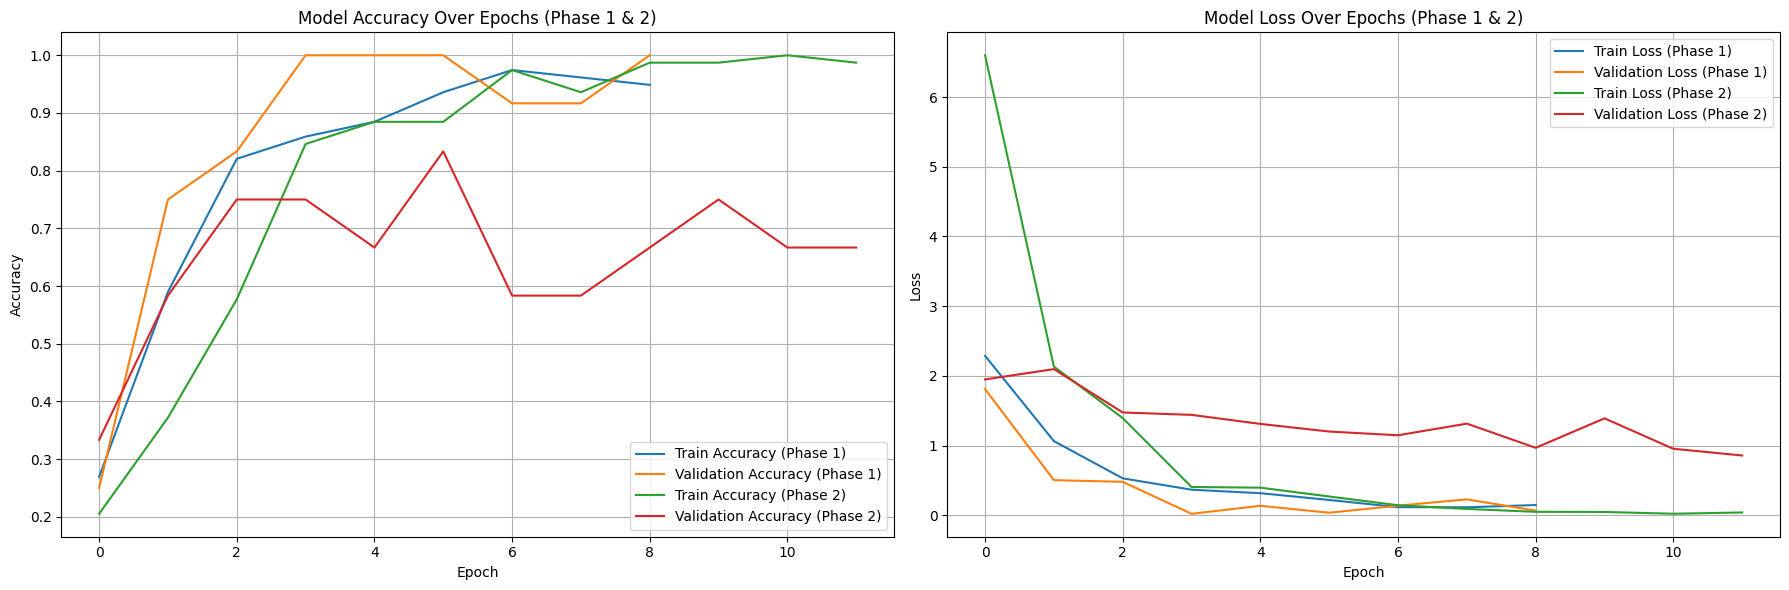

In [37]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values for Phase 1
plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
plt.plot(history_phase1.history['accuracy'], label='Train Accuracy (Phase 1)')
plt.plot(history_phase1.history['val_accuracy'], label='Validation Accuracy (Phase 1)')
plt.plot(history_phase2.history['accuracy'], label='Train Accuracy (Phase 2)')
plt.plot(history_phase2.history['val_accuracy'], label='Validation Accuracy (Phase 2)')
plt.title('Model Accuracy Over Epochs (Phase 1 & 2)')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True)

# Plot training & validation loss values for Phase 1
plt.subplot(1, 2, 2)
plt.plot(history_phase1.history['loss'], label='Train Loss (Phase 1)')
plt.plot(history_phase1.history['val_loss'], label='Validation Loss (Phase 1)')
plt.plot(history_phase2.history['loss'], label='Train Loss (Phase 2)')
plt.plot(history_phase2.history['val_loss'], label='Validation Loss (Phase 2)')
plt.title('Model Loss Over Epochs (Phase 1 & 2)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()